### Práctica

Puedes utilizar este notebook para analisar el dataset propuesto

In [71]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import seaborn as sns
# split para modelado
from sklearn.model_selection import train_test_split
# Scaled | Escalado
from sklearn.preprocessing import StandardScaler, MinMaxScaler
# Encoding | Codificación
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, OrdinalEncoder
# To save models
import json
import pickle
# Feature Selection
from sklearn.feature_selection import f_classif, SelectKBest



## levanto el csv a un df

In [72]:
df = pd.read_csv('../data/raw/p4ds_cadenas_unificadas_2025.csv')

In [73]:
df.head()

,Periodo,Grupo,Producto,Super,Precio
0,Abr25,Alimentos y bebidas,Aceite de girasol Marca Propia Envase 900 cc,Devoto,"80,00"
1,Abr25,Alimentos y bebidas,Aceite de girasol Marca Propia Envase 900 cc,Devoto Express,"99,00"
2,Abr25,Alimentos y bebidas,Aceite de girasol Marca Propia Envase 900 cc,Disco,"99,00"
3,Abr25,Alimentos y bebidas,Aceite de girasol Marca Propia Envase 900 cc,Ta - Ta,"95,00"
4,Abr25,Alimentos y bebidas,Aceite de girasol Marca Propia Envase 900 cc,Tienda Inglesa,"97,00"


### Analisis descriptivo

In [74]:
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:,.2f}'.format)

# Tamaño y columnas
print(f"Filas: {df.shape[0]}")
print(f"Columnas: {df.shape[1]}")
df.columns

# Tipos de datos y nulos
df.info()


# Resumen estadístico
df.describe(include='all')

# Valores nulos
nulos = df.isna().sum().sort_values(ascending=False)
nulos[nulos > 0]

# Duplicados
print("Filas duplicadas:", df.duplicated().sum())

df.duplicated()



Filas: 26834
Columnas: 5
<class 'pandas.DataFrame'>
RangeIndex: 26834 entries, 0 to 26833
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   Periodo   26834 non-null  str  
 1   Grupo     26671 non-null  str  
 2   Producto  26812 non-null  str  
 3   Super     24237 non-null  str  
 4   Precio    26401 non-null  str  
dtypes: str(5)
memory usage: 3.0 MB
Filas duplicadas: 1625


0        False
1        False
2        False
3        False
4        False
         ...  
26829    False
26830    False
26831    False
26832    False
26833    False
Length: 26834, dtype: bool

In [75]:
# Cantidad de valores únicos por columna
df.nunique().sort_values(ascending=False)

df[df.isnull().any(axis=1)]

df.isnull().any(axis=1).sum()

df.isnull().sum()

df_nulos = df[df.isnull().any(axis=1)]
df_nulos

,Periodo,Grupo,Producto,Super,Precio
1831,Abr25,NaN,Establecimientos Relevados,Devoto,"23,00"
1832,Abr25,NaN,Establecimientos Relevados,Devoto Express,"36,00"
1833,Abr25,NaN,Establecimientos Relevados,Disco,"29,00"
1834,Abr25,NaN,Establecimientos Relevados,El Clon,"16,00"
1835,Abr25,NaN,Establecimientos Relevados,El Dorado,"68,00"
...,...,...,...,...,...
26184,Dic25,Alimentos y bebidas,Harina trigo común 0000 Primor Paquete 1 kg.,Macro,NaN
26461,Dic25,Establecimientos Relevados,NaN,Disco,"300,00"
26516,Ene25,NaN,Establecimientos Relevados,Red Market,"60,00"
26624,Dic25,Establecimientos Relevados,NaN,Red Expres,"590,00"


In [76]:
df = df.dropna()

df.isnull().sum()


Periodo     0
Grupo       0
Producto    0
Super       0
Precio      0
dtype: int64

In [77]:
df.info()

df

<class 'pandas.DataFrame'>
Index: 23643 entries, 0 to 26833
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   Periodo   23643 non-null  str  
 1   Grupo     23643 non-null  str  
 2   Producto  23643 non-null  str  
 3   Super     23643 non-null  str  
 4   Precio    23643 non-null  str  
dtypes: str(5)
memory usage: 2.9 MB


,Periodo,Grupo,Producto,Super,Precio
0,Abr25,Alimentos y bebidas,Aceite de girasol Marca Propia Envase 900 cc,Devoto,"80,00"
1,Abr25,Alimentos y bebidas,Aceite de girasol Marca Propia Envase 900 cc,Devoto Express,"99,00"
2,Abr25,Alimentos y bebidas,Aceite de girasol Marca Propia Envase 900 cc,Disco,"99,00"
3,Abr25,Alimentos y bebidas,Aceite de girasol Marca Propia Envase 900 cc,Ta - Ta,"95,00"
4,Abr25,Alimentos y bebidas,Aceite de girasol Marca Propia Envase 900 cc,Tienda Inglesa,"97,00"
...,...,...,...,...,...
26829,Dic25,Cuidado personal,"Afeitadora Xtreme3 Piel Delicada X1, 1 unidad",Devoto Express,"1010,00"
26830,Mar25,Cuidado personal,"Perfume Delice Candy, 50 ml.",Farmashop,"6210,00"
26831,Feb25,Cuidado personal,"Toallitas Femeninas Ladysoft Basica, 16 us.",Tienda Inglesa,"1780,00"
26832,Dic25,Frutas y verduras,"Papa Blanca, 1 kg.",Disco,"1090,00"


### Observaciones:

Una vez revisada la información del dataframe, se pueden extraer las siguientes conclusiones:

- El dataset contiene un total de **26.834 filas** y **5 columnas**: `Periodo`, `Grupo`, `Producto`, `Super` y `Precio`.
- La variable `Periodo` no tiene valores nulos, por lo que todas las filas cuentan con un período asociado.
- La variable con mayor cantidad de valores nulos es `Super`, con **2.597 valores faltantes**.
- La variable `Precio` tiene **433 valores nulos**, por lo que hay productos/registros sin precio informado.
- La variable `Grupo` tiene **163 valores nulos** y `Producto` tiene **22 valores nulos**.
- En total, existen **3.191 filas con al menos un valor nulo**.
- Si se eliminan todas las filas con valores nulos usando `df.dropna()`, el dataset queda con **23.643 filas**.
- Todas las columnas aparecen inicialmente como categóricas/texto (`object` o `str`), incluso `Precio`.
- La columna `Precio` debería transformarse a numérica, ya que actualmente usa coma decimal, por ejemplo `80,00`.
- El dataset contiene información de **12 períodos**, **10 grupos**, **427 productos** y **17 supermercados** distintos.


## Limpieza de datos

### Eliminación de duplicados

In [78]:
df.duplicated()

0        False
1        False
2        False
3        False
4        False
         ...  
26829    False
26830    False
26831    False
26832    False
26833    False
Length: 23643, dtype: bool

In [79]:
df.duplicated().sum()

np.int64(1511)

In [80]:
df = df.drop_duplicates().reset_index(drop=True)

In [81]:
df.duplicated().sum()

np.int64(0)

### Normalizacion de columnas

In [82]:
df["Grupo"].value_counts(dropna=False)
df["Grupo"] = df["Grupo"].str.strip().str.lower()

df["Grupo"] = df["Grupo"].str.strip().str.lower().str.capitalize()

# Verifico
df["Grupo"].value_counts(dropna=False)


Grupo
Alimentos y bebidas    13054
Cuidado personal        6685
Limpieza del hogar      1475
Frutas y verduras        901
Familia                   17
Name: count, dtype: int64

In [83]:
columnas_texto = ["Periodo", "Grupo", "Producto", "Super"]

for col in columnas_texto:
    df[col] = df[col].str.strip()

df["Grupo"] = df["Grupo"].str.strip().str.lower().str.capitalize()
df["Super"] = df["Super"].str.strip().str.title()
df["Producto"] = df["Producto"].str.strip().str.lower()

df["Periodo"] = df["Periodo"].str.strip()
df["Grupo"] = df["Grupo"].str.strip().str.lower().str.capitalize()
df["Producto"] = df["Producto"].str.strip().str.lower()
df["Super"] = df["Super"].str.strip().str.title()

#Verifico
df.nunique()

df["Grupo"].value_counts()
df["Super"].value_counts()

Super
Red Expres        2065
Tienda Inglesa    2052
Red Market        2015
Disco             1799
Devoto            1769
Ta - Ta           1748
El Dorado         1620
Macro             1619
Devoto Express    1476
Micro Macro       1442
El Clon           1080
Farmashop          763
Farmaglobal        724
Frog               717
Kinko              486
San Roque          409
Pigalle            348
Name: count, dtype: int64

## Limpieza de datos: Eliminación de información irrelevante

### Conclusión
#### No tenemos datos irrelevantes a eliminar, todos aportan valor al analisis

### Paso 4: Análisis de variables

#### Análisis de Variables Univariante Categóricas

Una **variable categórica** es un tipo de variable que puede tomar uno de un número limitado de categorías o grupos. Estos grupos suelen ser nominales, es decir, representan nombres o clases sin un orden numérico natural.

En este dataset, las variables categóricas permiten identificar dimensiones como el período relevado, el grupo de producto, el producto específico y el supermercado donde se registró el precio.

Antes de comenzar a graficar, debemos identificar cuáles son categóricas. En este caso, las variables categóricas son: `Periodo`, `Grupo`, `Producto` y `Super`.

La variable `Precio` no se considera categórica para el análisis, ya que representa un valor monetario y debería analizarse como variable numérica una vez convertida correctamente.

In [84]:
df.dtypes

variables_categoricas = ["Periodo", "Grupo", "Producto", "Super"]

df[variables_categoricas].nunique()


Periodo      12
Grupo         5
Producto    427
Super        17
dtype: int64

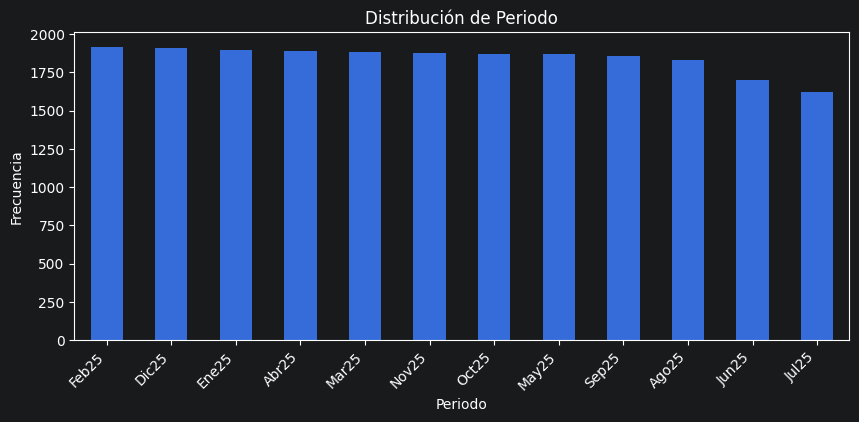

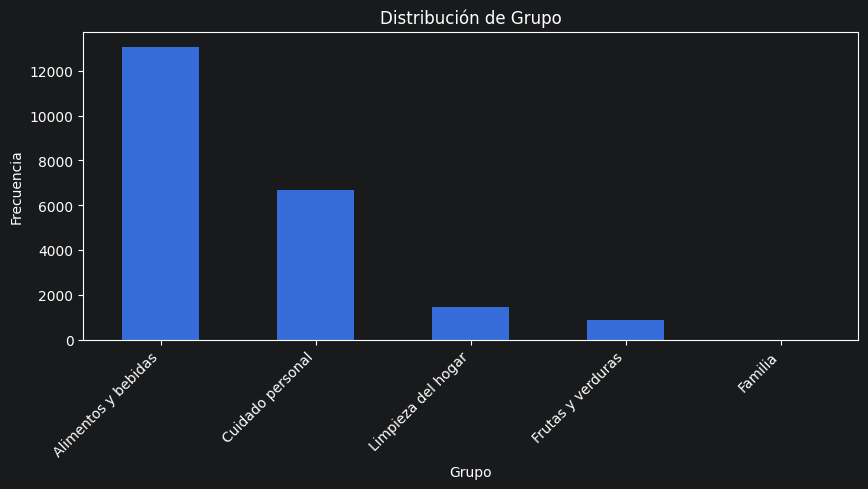

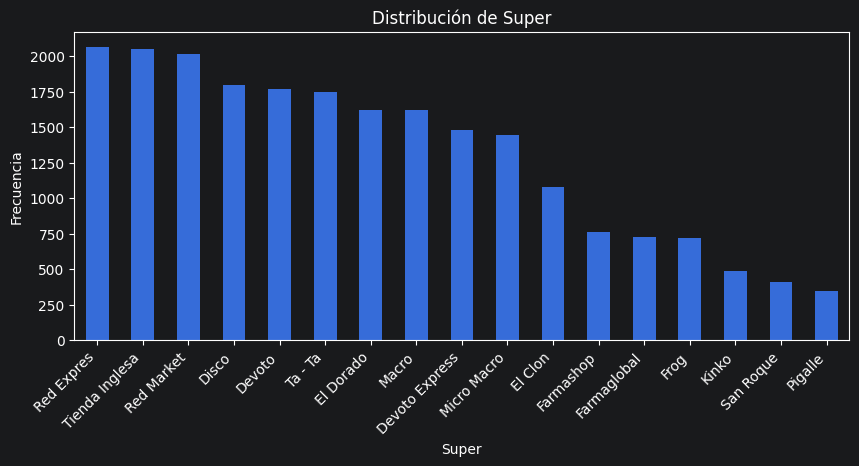

In [85]:
variables_categoricas = ["Periodo", "Grupo", "Super"]

for col in variables_categoricas:
    plt.figure(figsize=(10, 4))
    df[col].value_counts().plot(kind="bar")
    plt.title(f"Distribución de {col}")
    plt.xlabel(col)
    plt.ylabel("Frecuencia")
    plt.xticks(rotation=45, ha="right")
    plt.show()

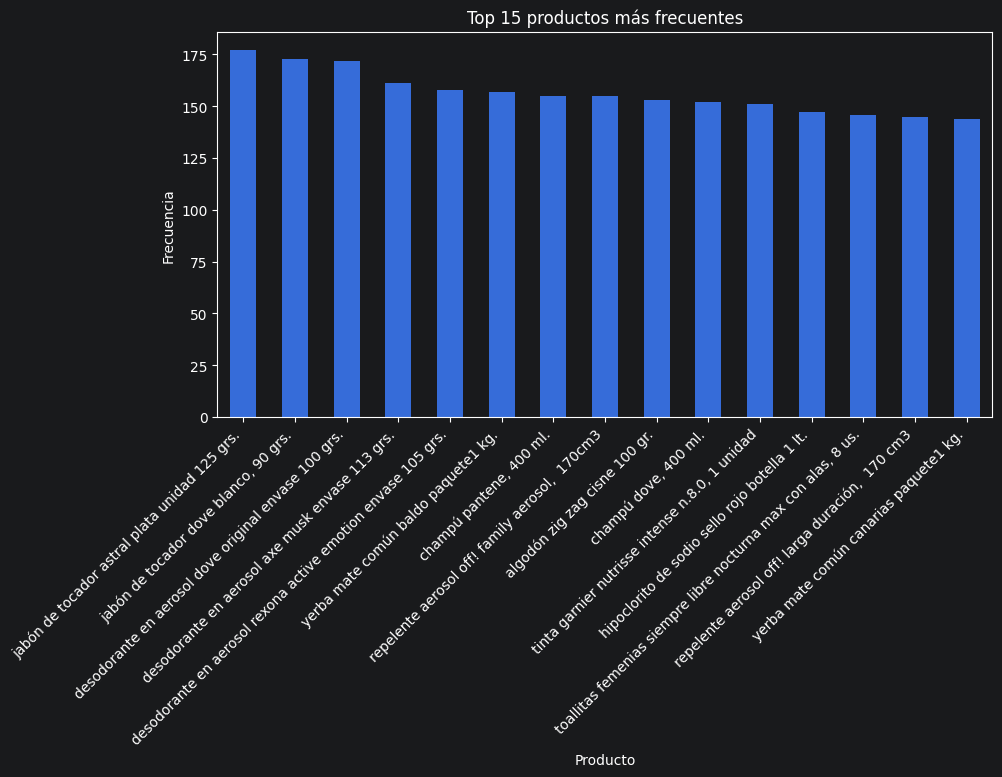

In [86]:
plt.figure(figsize=(10, 5))
df["Producto"].value_counts().head(15).plot(kind="bar")
plt.title("Top 15 productos más frecuentes")
plt.xlabel("Producto")
plt.ylabel("Frecuencia")
plt.xticks(rotation=45, ha="right")
plt.show()

In [87]:
# Limpieza básica del precio
df['Precio'] = (
    df['Precio']
    .astype(str)
    .str.replace('.', '', regex=False)
    .str.replace(',', '.', regex=False)
    .astype(float)
)


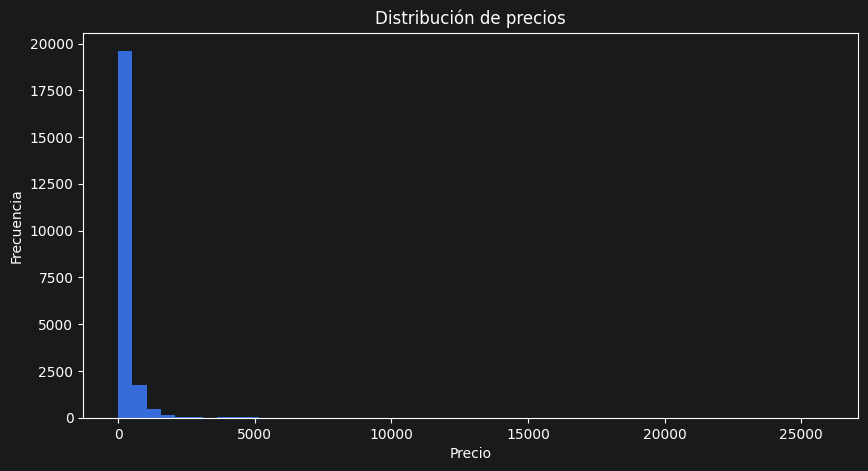

<Figure size 1000x500 with 0 Axes>

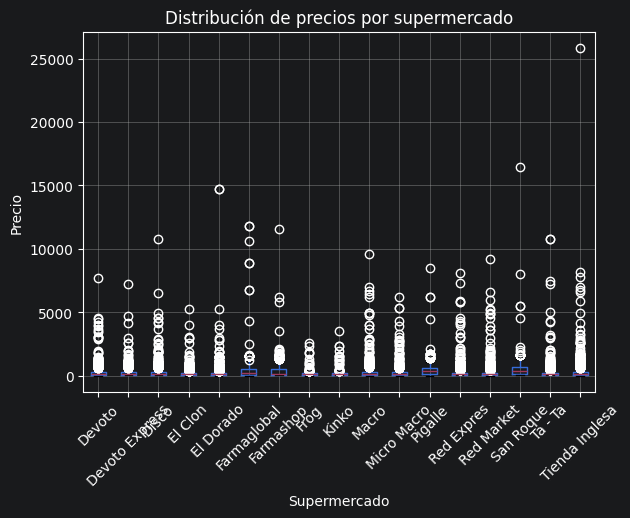

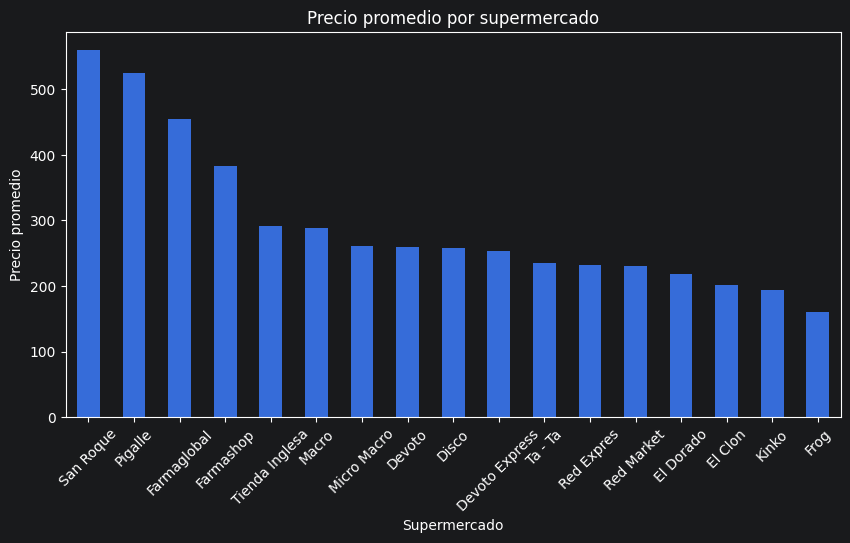

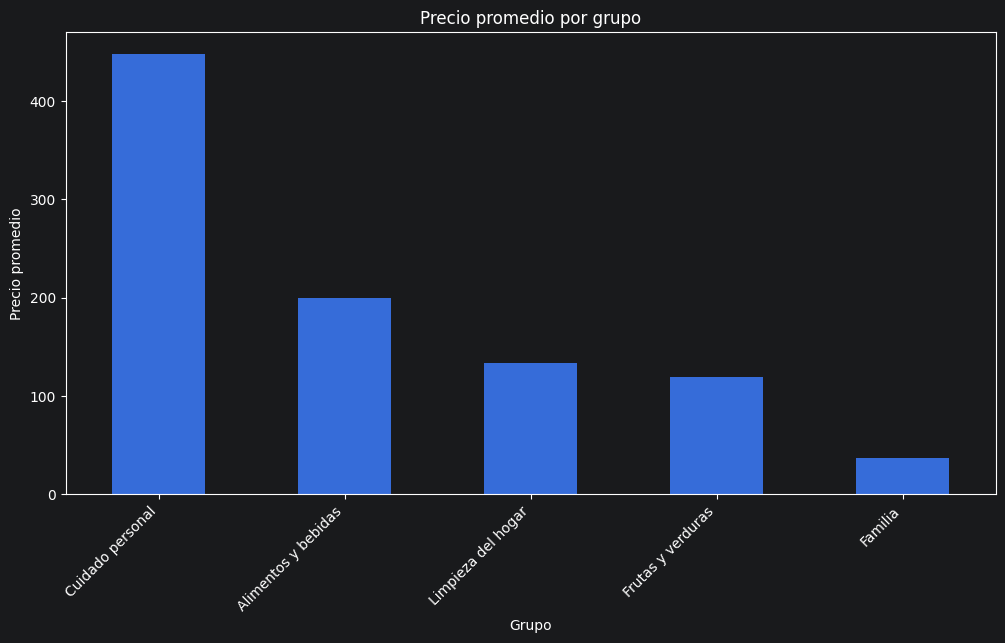

Super,Devoto,Devoto Express,Disco,El Clon,El Dorado,Farmaglobal,Farmashop,Frog,Kinko,Macro,Micro Macro,Pigalle,Red Expres,Red Market,San Roque,Ta - Ta,Tienda Inglesa,diferencia_max_min
Producto,,,,,,,,,,,,,,,,,,
protector solar spf 50 eucerin 150 ml.,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"1,657.88",NaN,NaN,NaN,NaN,"7,224.00","5,566.12"
panales para ninos comun babysec (48 unidades),"1,133.00",NaN,"4,316.00",989.00,974.00,"1,184.50","4,628.00",NaN,NaN,"1,045.65",NaN,NaN,"1,017.00","1,060.00","1,104.00","1,085.00","1,157.00","3,654.00"
"crema facial revitalift filler dia, 50 ml.",NaN,NaN,NaN,NaN,"3,672.50","1,598.20","1,583.00",NaN,NaN,"1,593.65",NaN,NaN,NaN,NaN,NaN,839.00,"1,582.00","2,833.50"
protector solar spf 50 hawaiian tropic (240 ml.),"1,106.00",NaN,"1,106.00",NaN,NaN,"1,156.50","1,055.00",NaN,NaN,NaN,NaN,"1,055.00","1,058.00","3,680.00","1,030.00",NaN,"1,139.00","2,650.00"
chorizo suelto centenario-extra (1 kg.),"3,076.67",NaN,749.00,NaN,NaN,NaN,NaN,NaN,NaN,653.20,653.20,NaN,NaN,"2,060.00",NaN,639.00,654.50,"2,437.67"
perfume comun bebe & co. (120 ml.),676.00,NaN,676.00,NaN,NaN,738.95,681.00,NaN,NaN,735.70,794.50,655.00,640.50,599.00,745.00,"3,000.00",673.50,"2,401.00"
"pañales babysec premium extra extra grande, 48 us.","1,074.50","1,163.65","1,074.50",967.00,928.44,"2,961.28","1,174.00",NaN,NaN,"1,027.30",NaN,NaN,"1,033.30","1,057.65","1,123.00","2,753.58","1,091.00","2,032.83"
protector solar spf 40 dermaglós 250 ml.,NaN,NaN,NaN,NaN,NaN,NaN,"1,636.40",NaN,NaN,NaN,NaN,"1,374.30",NaN,NaN,"2,996.36",NaN,"1,708.40","1,622.06"
"pañales huggies primeros 100 dias pequeño, 40 us.",639.33,672.33,639.33,NaN,726.60,"2,189.06",736.90,NaN,NaN,"1,578.10","1,131.96",625.14,671.50,727.30,753.10,630.00,"1,232.73","1,563.92"


In [88]:
# Frecuencia por supermercado
df['Super'].value_counts()

# Frecuencia por grupo
df['Grupo'].value_counts()

# Frecuencia por periodo
df['Periodo'].value_counts().sort_index()

# Precio promedio por supermercado
df.groupby('Super')['Precio'].agg(['count', 'mean', 'median', 'min', 'max']).sort_values('mean', ascending=False)

# Precio promedio por grupo
df.groupby('Grupo')['Precio'].agg(['count', 'mean', 'median', 'min', 'max']).sort_values('mean', ascending=False)

# Productos más caros en promedio
df.groupby('Producto')['Precio'].mean().sort_values(ascending=False).head(20)

# Productos más baratos en promedio
df.groupby('Producto')['Precio'].mean().sort_values().head(20)

# Histograma de precios
plt.figure(figsize=(10, 5))
plt.hist(df['Precio'], bins=50)
plt.title('Distribución de precios')
plt.xlabel('Precio')
plt.ylabel('Frecuencia')
plt.show()

# Boxplot de precios por supermercado
plt.figure(figsize=(10, 5))
df.boxplot(column='Precio', by='Super', rot=45)
plt.title('Distribución de precios por supermercado')
plt.suptitle('')
plt.xlabel('Supermercado')
plt.ylabel('Precio')
plt.show()

# Precio promedio por supermercado
precio_super = df.groupby('Super')['Precio'].mean().sort_values(ascending=False)

plt.figure(figsize=(10, 5))
precio_super.plot(kind='bar')
plt.title('Precio promedio por supermercado')
plt.xlabel('Supermercado')
plt.ylabel('Precio promedio')
plt.xticks(rotation=45)
plt.show()

# Precio promedio por grupo
precio_grupo = df.groupby('Grupo')['Precio'].mean().sort_values(ascending=False)

plt.figure(figsize=(12, 6))
precio_grupo.plot(kind='bar')
plt.title('Precio promedio por grupo')
plt.xlabel('Grupo')
plt.ylabel('Precio promedio')
plt.xticks(rotation=45, ha='right')
plt.show()

# Comparación supermercado vs grupo
tabla_super_grupo = pd.pivot_table(
    df,
    values='Precio',
    index='Grupo',
    columns='Super',
    aggfunc='mean'
)

tabla_super_grupo

# Diferencia entre supermercados por producto
comparacion_productos = pd.pivot_table(
    df,
    values='Precio',
    index='Producto',
    columns='Super',
    aggfunc='mean'
)

comparacion_productos['diferencia_max_min'] = comparacion_productos.max(axis=1) - comparacion_productos.min(axis=1)

comparacion_productos.sort_values('diferencia_max_min', ascending=False).head(20)

#### Observaciones

A partir de los gráficos de las variables categóricas, se pueden extraer las siguientes conclusiones:

- **Periodo**: El dataset contiene registros para los 12 meses de 2025. La distribución es bastante pareja entre meses, aunque `Dic25`, `Feb25`, `Ene25` y `Abr25` son los períodos con mayor cantidad de registros. `Jul25` es el período con menor cantidad.
- **Grupo**: La categoría con mayor presencia es `Alimentos y bebidas`, con una diferencia importante frente al resto. Le siguen `Cuidado personal`, `Limpieza del hogar` y `Frutas y verduras`.
- **Grupo**: Antes de normalizar los textos, algunas categorías aparecían duplicadas por diferencias de mayúsculas y minúsculas, por ejemplo `Alimentos y bebidas` y `alimentos y bebidas`. Esto fue corregido al estandarizar el texto.
- **Super**: Existen registros para varios supermercados. Los que tienen mayor cantidad de observaciones son `Red Expres`, `Tienda Inglesa`, `Red Market`, `Disco`, `Devoto` y `Ta - Ta`.
- **Super**: También se observa una cantidad importante de registros sin supermercado informado, por lo que esta variable tenía valores nulos relevantes.
- **Producto**: Es la variable categórica con mayor variedad de valores. Esto es esperable, ya que el dataset contiene muchos productos distintos.
- **Producto**: Debido a la gran cantidad de productos, no conviene analizar todos en un único gráfico de barras. Es más claro observar solo los productos más frecuentes, por ejemplo el top 10 o top 15.

#### Análisis de Variables Univariante Numéricas

Una **variable numérica** es un tipo de variable que puede tomar valores numéricos, como enteros, decimales o valores monetarios. Normalmente se representa utilizando un histograma, para observar su distribución, y un gráfico de caja o boxplot, para identificar valores atípicos.

En este dataset, la principal variable numérica es `Precio`, ya que representa el valor monetario registrado para cada producto en cada supermercado y período.

Sin embargo, antes de graficarla es necesario convertirla a formato numérico, porque originalmente aparece como texto y utiliza coma decimal, por ejemplo `80,00`.

Por lo tanto, la variable numérica a analizar será: `Precio`.

In [89]:
df["Precio"].describe()



count   22,132.00
mean       266.82
std        556.77
min          6.00
25%         75.50
50%        132.00
75%        279.00
max     25,800.00
Name: Precio, dtype: float64

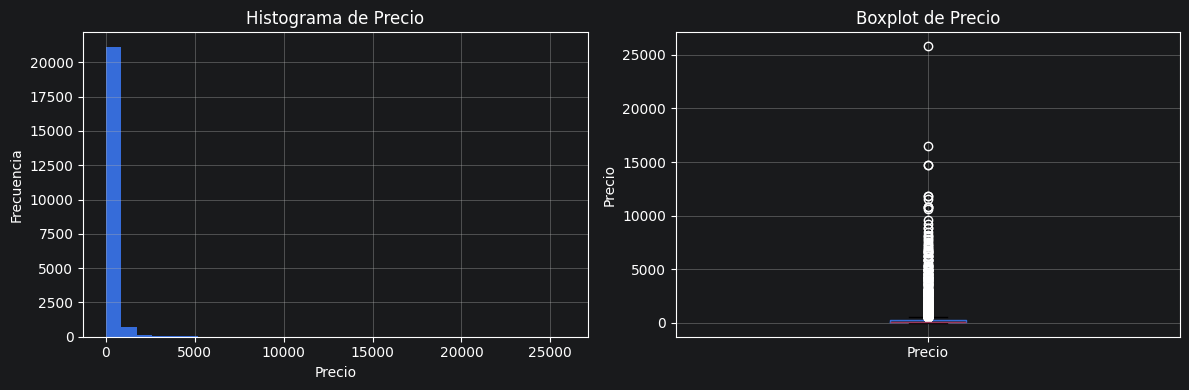

In [90]:
#Grafico

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

df["Precio"].hist(ax=axes[0], bins=30)
axes[0].set_title("Histograma de Precio")
axes[0].set_xlabel("Precio")
axes[0].set_ylabel("Frecuencia")

df.boxplot(column="Precio", ax=axes[1])
axes[1].set_title("Boxplot de Precio")
axes[1].set_ylabel("Precio")

plt.tight_layout()
plt.show()

In [91]:
# Quito outliers usando el metodo del rango intercuartílico (`IQR`):

Q1 = df["Precio"].quantile(0.25)
Q3 = df["Precio"].quantile(0.75)
IQR = Q3 - Q1

limite_inferior = Q1 - 1.5 * IQR
limite_superior = Q3 + 1.5 * IQR

df_sin_outliers = df[
    (df["Precio"] >= limite_inferior) &
    (df["Precio"] <= limite_superior)
].copy()

df_sin_outliers.shape

df.shape[0] - df_sin_outliers.shape[0]


2211

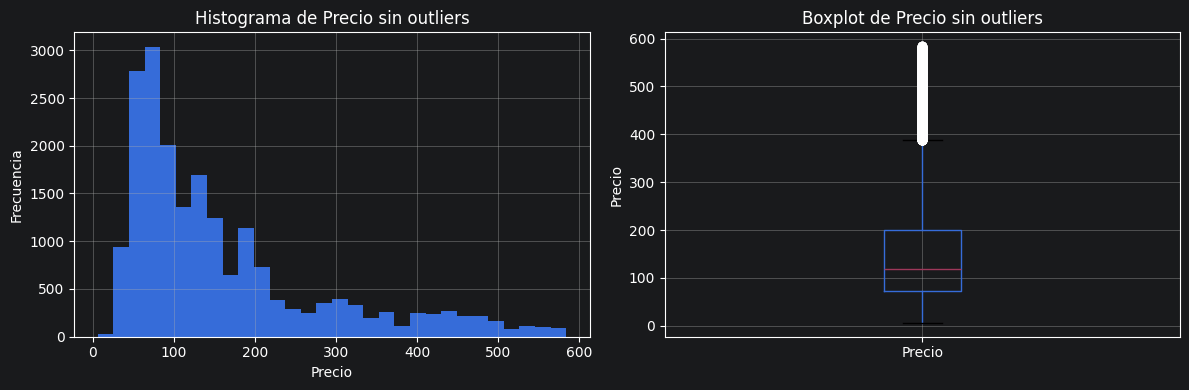

In [92]:
#grafico nuevamente
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

df_sin_outliers["Precio"].hist(ax=axes[0], bins=30)
axes[0].set_title("Histograma de Precio sin outliers")
axes[0].set_xlabel("Precio")
axes[0].set_ylabel("Frecuencia")

df_sin_outliers.boxplot(column="Precio", ax=axes[1])
axes[1].set_title("Boxplot de Precio sin outliers")
axes[1].set_ylabel("Precio")

plt.tight_layout()
plt.show()

In [93]:
df = df_sin_outliers.reset_index(drop=True)

df_outliers = df[
    (df["Precio"] < limite_inferior) |
    (df["Precio"] > limite_superior)
]

df_outliers.sort_values("Precio", ascending=False).head(20)

,Periodo,Grupo,Producto,Super,Precio


#### Observaciones:

- La combinación del histograma y el boxplot permite analizar la distribución de la variable `Precio` y detectar posibles valores atípicos.
- La variable `Precio` presenta una distribución claramente asimétrica hacia la derecha, ya que la mayoría de los precios se concentran en valores bajos y medios, mientras que existen algunos precios extremadamente altos.
- La mediana del precio es **129**, mientras que la media es aproximadamente **238,65**. Esto indica que los valores altos elevan el promedio.
- El valor mínimo registrado es **6**, mientras que el valor máximo llega a **25.800**, lo cual confirma la presencia de valores atípicos.
- Según el criterio del rango intercuartílico (`IQR`), se consideran outliers los precios superiores a aproximadamente **510**.
- Se identifican alrededor de **2.471 registros atípicos** en la variable `Precio`.
- Estos outliers pueden corresponder a productos efectivamente más caros, errores de carga o productos de categorías muy distintas, por lo que conviene revisarlos antes de eliminarlos definitivamente.
- Para mejorar la visualización general de la distribución, puede trabajarse con un dataframe sin outliers, especialmente si el objetivo es analizar precios típicos.

In [94]:
#El límite inferior da negativo, los outliers relevantes son los precios altos:
df_outliers = df[df["Precio"] > limite_superior].copy()

#Para ver los más extremos:
df_outliers.sort_values("Precio", ascending=False).head(20)

,Periodo,Grupo,Producto,Super,Precio


In [95]:
#Para analizar por grupo:
df_outliers["Grupo"].value_counts()

#Para analizar por supermercado:
df_outliers["Super"].value_counts()

#Para analizar por producto:
df_outliers["Producto"].value_counts().head(20)

#Comparar estadísticas entre datos normales y outliers:
df["Precio"].describe()

df_outliers["Precio"].describe()


#porcentaje de outliers:

len(df_outliers) / len(df) * 100

# Para una tabla más útil:
df_outliers.groupby("Grupo")["Precio"].agg(
    cantidad="count",
    minimo="min",
    mediana="median",
    promedio="mean",
    maximo="max"
).sort_values("cantidad", ascending=False)


# Por producto
df_outliers.groupby("Producto")["Precio"].agg(
    cantidad="count",
    minimo="min",
    mediana="median",
    promedio="mean",
    maximo="max"
).sort_values("maximo", ascending=False).head(20)


,cantidad,minimo,mediana,promedio,maximo
Producto,,,,,


### Análisis de Variables Multivariante

Tras analizar las variables una a una, es momento de estudiar cómo se relacionan entre sí. En este dataset no existe una variable objetivo o predictora como `Survived` en el caso del Titanic, por lo que el análisis multivariante se enfoca en entender cómo cambia la variable `Precio` según otras variables del dataset.

El objetivo principal es analizar si los precios varían según el `Grupo`, el `Producto`, el `Super` o el `Periodo`. Esto permite obtener conclusiones más claras sobre el comportamiento de los precios y tomar mejores decisiones sobre limpieza, eliminación de valores nulos u outliers.

Por ejemplo, la variable `Precio` presenta valores atípicos. Antes de eliminarlos, es importante revisar si estos outliers pertenecen a productos específicos, supermercados concretos o determinados grupos. Algunos precios altos podrían no ser errores, sino productos naturalmente más caros, como cremas, protectores solares o pañales.

Del mismo modo, la variable `Super` tiene una cantidad importante de valores nulos. Antes de eliminar esas filas, conviene analizar si esos registros tienen precios, productos o grupos relevantes, ya que podrían aportar información útil al análisis.

Por lo tanto, en este análisis multivariante se estudiará principalmente la relación entre `Precio` y las variables categóricas `Grupo`, `Producto`, `Super` y `Periodo`.

In [96]:
df.groupby("Grupo")["Precio"].describe()
df.groupby("Super")["Precio"].describe()
df.groupby("Periodo")["Precio"].describe()

#Para ver precios promedio por grupo:
df.groupby("Grupo")["Precio"].mean().sort_values(ascending=False)
#Para ver precios promedio por supermercado:
df.groupby("Super")["Precio"].mean().sort_values(ascending=False)
#Para ver precios promedio por mes:
df.groupby("Periodo")["Precio"].mean().sort_values(ascending=False)

#Y para analizar outliers por grupo:
df_outliers.groupby("Grupo")["Precio"].agg(
    cantidad="count",
    minimo="min",
    mediana="median",
    promedio="mean",
    maximo="max"
).sort_values("cantidad", ascending=False)

,cantidad,minimo,mediana,promedio,maximo
Grupo,,,,,


In [97]:

# Crear carpeta si no existe
processed_path = Path('../data/processed')
processed_path.mkdir(parents=True, exist_ok=True)

# Guardar como Excel
df.to_excel(processed_path / 'cadenas_unificadas_2025_procesado.xlsx', index=False)